## Clusterização com o K-Means

Colab de referência: https://colab.research.google.com/drive/1SsSG-x5pZRPaQ_NhL-Gvpcz50QAzpPP-#scrollTo=X1YLBHt_lOIX

In [3]:
import pandas as pd

url = 'https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv'
iris = pd.read_csv(url)

iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Separação dos dados

In [7]:
X = iris.iloc[: , 0:4].values # Separa somente as colunas das características

### Redução de dimensionalidade com t-SNE

* Antes de aplicar o algoritmo k-means, vamos reduzir a dimensionalidade dos dados usando t-SNE (*t-Distributed Stochastic Neighbor Embedding*).
* O t-SNE é uma técnica de redução de dimensionalidade particularmente útil para visualizar dados de alta dimensão.
* Ele transforma os dados de um espaço de características de alta dimensão para um espaço de 2 ou 3 dimensões, mantendo as relações de proximidade entre as amostras, o que é ideal para visualizar agrupamentos em um gráfico.

In [10]:
from sklearn.manifold import TSNE # Classe para redução da dimensionalidade
X_tsne = TSNE(n_components=2).fit_transform(X) # Reduz de 4 para 2 características

In [11]:
# Transformar de 4 características para apenas 2.
X_tsne.shape

(150, 2)

### Preparação para visualização

In [14]:
data_tsne = pd.DataFrame(X_tsne) # Transforma as amostras obtidas pelo TSNE em DataFrame
classes = iris.iloc[: , 4] # Extrai a coluna dos rótulos das classes
data_tsne.insert(2, 'classe', classes) # Reúne as amostras e os rótulos das classes
data_tsne = data_tsne.rename(columns = {0: "carac_tsne_0", 1: "carac_tsne_1"}) # Altera os nomes das colunas

In [15]:
data_tsne.head()

,carac_tsne_0,carac_tsne_1,classe
0,-23.197245,-2.327950,setosa
1,-20.457767,-1.380954,setosa
2,-20.734205,-2.607441,setosa
3,-20.227306,-2.237028,setosa
4,-23.278816,-2.592806,setosa


### Visualizando os dados

<Axes: xlabel='carac_tsne_0', ylabel='carac_tsne_1'>

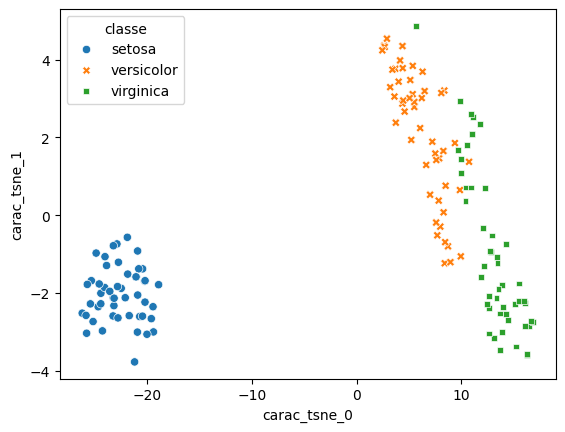

In [16]:
import seaborn as sns
sns.scatterplot(x = data_tsne['carac_tsne_0'], y = data_tsne['carac_tsne_1'], hue = data_tsne.classe, style = data_tsne.classe)

### Aplicando o K-Means

- **n_clusters**: Define o número de clusters a serem formados. Como sabemos que o dataset Iris tem três classes, usamos `n_clusters=3`. EM uma aplicação no mundo real esse número poderia ser escolhido com base no objetivo do agrupamento ou no deliamento experimental realizado por um especialista.
- **init**: Método para inicialização dos centroides. Usamos `random` para escolher centroides iniciais aleatoriamente.
- **n_init**: Número de vezes que o algoritmo k-means será executado com diferentes centroides iniciais. O melhor resultado (com menor inércia) é retornado.
- **max_iter**: Número máximo de iterações para uma única execução do k-means.
- **tol**: Tolerância para declarar convergência, ou seja, o critério de parada baseado em pequenas variações na inércia.
- **random_state**: Define a semente do gerador de números aleatórios para garantir reprodutibilidade.

In [19]:
from sklearn.cluster import KMeans # Importação do algoritmo k - means
km = KMeans(n_clusters=3, init = 'random', n_init=10, max_iter=300,  tol=1e-04, random_state=42) # Parametrização do modelo
km.fit(X_tsne) # Computa os centroides dos clusters

,n_clusters,3
,init,'random'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


### Predição e atribuição aos clusters

In [23]:
predicao = km.predict(X_tsne) # Associa os objetos aos índices da classe

### Visualizando os clusters e centróides

* `X_tsne[predicao == 0, 0]`: Combina a matriz `X_tsne` com a máscara booleana para selecionar todas as amostras (linhas) que pertencem ao cluster `0`. O `, 0` no final do índice indica que estamos interessados apenas na primeira coluna (a primeira dimensão) dessas amostras. Já `X_tsne[predicao == 0, 1]` fornece os valores das características da segunda coluna.
* `s = 50`: Define o tamanho dos marcadores (pontos) no gráfico. Aqui, `s = 50` significa que cada ponto terá um tamanho moderado.
* `c = 'lightgreen'`: Define a cor dos marcadores como verde claro (lightgreen), o que facilita a visualização e a distinção dos pontos pertencentes ao cluster 0.
* `marker = 's'`: Define o formato dos marcadores como quadrados (`s`), diferenciando visualmente os pontos deste cluster dos de outros clusters que podem usar formatos diferentes.
* `edgecolor = 'black'`: Define a cor da borda dos marcadores como preta, o que pode ajudar a destacar os marcadores no gráfico, especialmente se a cor de preenchimento for clara.
* `label = 'cluster 0'`: Define o rótulo (label) deste conjunto de pontos como "cluster 0". Esse rótulo será utilizado na legenda do gráfico, permitindo identificar visualmente quais pontos pertencem ao cluster 0.

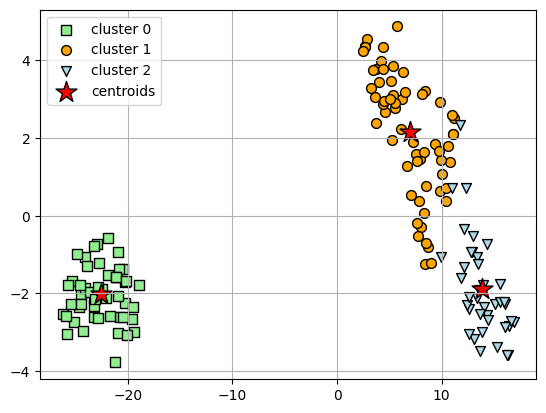

In [24]:
from matplotlib import pyplot as plt
plt.scatter(X_tsne[predicao == 0, 0], X_tsne[predicao == 0, 1], s = 50, c = 'lightgreen', marker = 's', edgecolor = 'black', label = 'cluster 0')
plt.scatter(X_tsne[predicao == 1, 0], X_tsne[predicao == 1, 1], s = 50,  c = 'orange', marker = 'o', edgecolor = 'black',  label = 'cluster 1')
plt.scatter(X_tsne[predicao == 2, 0], X_tsne[predicao == 2, 1], s = 50, c = 'lightblue', marker = 'v', edgecolor = 'black', label = 'cluster 2')

# Plota os centroides de cada cluster
plt.scatter(km.cluster_centers_[: , 0], km.cluster_centers_[: , 1], s = 250, marker = '*', c = 'red', edgecolor = 'black', label = 'centroids')
plt.legend(scatterpoints = 1)
plt.grid()